MSE  : 3035260335.335514
RMSE : 55093.19681535565
MAE  : 42725.31945629963
R2   : 0.23114946290024685


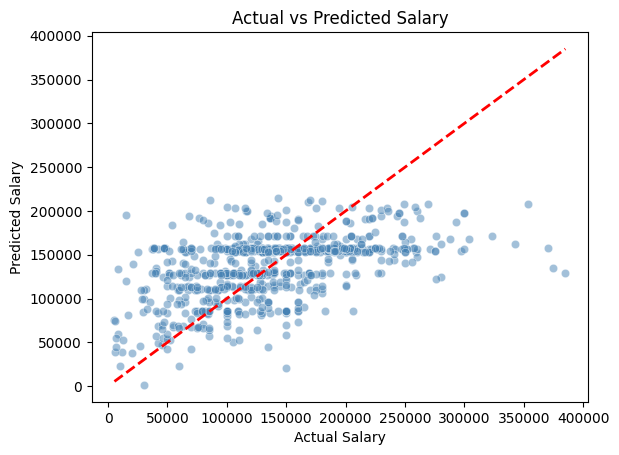

['model.pkl']

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# DATA
df = pd.read_csv("ds_salaries.csv")

# Select Features
FEATURES = ['experience_level', 'employment_type', 'job_title',
            'company_size', 'remote_ratio']
TARGET = 'salary_in_usd'

data = df[FEATURES + [TARGET]].dropna()
X = data[FEATURES]
y = data[TARGET]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define column types
categorical_cols = ['experience_level', 'employment_type', 'job_title', 'company_size']
numerical_cols = ['remote_ratio']

# ColumnTransformer: different processing for different column types
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Pipeline: chains preprocessing + model into ONE object
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MSE  : {mse}")
print(f"RMSE : {rmse}")
print(f"MAE  : {mae}")
print(f"R2   : {r2}")

# Actual vs Predicted plot
plt.figure()
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.show()

# Save the trained pipeline
joblib.dump(pipeline, 'model.pkl')
